# TPOSE24 validation vs AVISO / DUACS (sea-surface height)

Daily AVISO/DUACS absolute dynamic topography (`adt`) is compared to the model dynamic sea-surface height (`ETAN`) over the model domain and run period (Oct–Dec 2012).

Model `ETAN` and AVISO `adt` use different vertical references (geoid / mean-dynamic-topography conventions), so an absolute offset is meaningless.  We therefore compare **anomalies**: the per-pixel temporal mean over the evaluation window is removed from both fields, and the residual day-to-day SSH variability is compared.  The time-mean spatial pattern is shown separately with its domain mean removed (the dynamic-topography / zonal-tilt signal).

**1-D**: SSH-anomaly RMSE time series + box summary; time-mean SSH (domain-mean removed) vs longitude on the equator (the zonal pressure-gradient signal); SSH-anomaly standard deviation vs longitude.

**2-D**: maps of time-mean SSH (domain-mean removed), of SSH-anomaly variability (std), and of the time-mean SSH difference (model − AVISO).

In [1]:
# ════════════════════════════════════════════════════════════════════
#  MODEL RUNS TO VALIDATE
#  Each entry is (label_for_figures, run_directory).
#  Add or remove entries here — every figure below updates its number
#  of lines / panels automatically.
# ════════════════════════════════════════════════════════════════════
MODELS = [
    ('Ri7', '/data/SO3/edavenport/tpose24/oct2012_3mo_dt300_AB3'),
    ('Ri3', '/data/SO3/edavenport/tpose24/oct2012_TP6Vel_3month_Ri3'),
    ('Ri5', '/data/SO3/edavenport/tpose24/oct2012_TP6Vel_3month_Ri5'),
]

OUTDIR    = 'AVISO_comparison'
AVISO_OBS = '/home/edavenport/analysis/vel-assim-manuscript/forecasts/aviso_data/aviso_equatorial_pacific.nc'


In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cmocean.cm as cmo

import obs_validation_utils as u

plt.rcParams.update({'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11})
os.makedirs(OUTDIR, exist_ok=True)
print(f'{len(MODELS)} model run(s):', [m[0] for m in MODELS])
print('Figures ->', OUTDIR)


3 model run(s): ['Ri7', 'Ri3', 'Ri5']
Figures -> AVISO_comparison


In [3]:
# ── Load AVISO once (longitude -> 0:360) ─────────────────────────────
aviso_ds = u.to_0360(xr.open_dataset(AVISO_OBS, chunks={'time': 50}))
print('AVISO vars:', list(aviso_ds.data_vars))
print('AVISO time:', str(aviso_ds.time.values[0])[:10], '->',
      str(aviso_ds.time.values[-1])[:10])


AVISO vars: ['sla', 'adt']
AVISO time: 2010-01-01 -> 2020-12-31


In [4]:
# ── Load every model SSH (ETAN), regrid onto AVISO, align in time ────
def demean_time(arr):
    """Remove the per-pixel temporal mean (-> SSH anomaly)."""
    return arr - np.nanmean(arr, axis=0, keepdims=True)

results = {}
obs_ssh = None

for i, (label, run_dir) in enumerate(MODELS):
    print(f'[{label}] loading {run_dir}')
    ds    = u.load_tpose24(run_dir, prefix=['diag_surf'])
    etan  = ds.ETAN.where(ds.ETAN != 0)
    etand = u.daily_mean(etan)

    if obs_ssh is None:
        dom = u.model_domain(ds)
        print('   domain =', tuple(round(d, 2) for d in dom))
        t0 = str(etand.time.values[0])[:10]
        t1 = str(etand.time.values[-1])[:10]
        obs_sub = (u.subset_domain(aviso_ds.adt, *dom)
                     .sel(time=slice(t0, t1)).compute())

    mod = u.regrid_model_to_obs(etand, obs_sub.longitude,
                                obs_sub.latitude).compute()
    mod_a, obs_a = u.align_daily(mod, obs_sub)
    if obs_ssh is None:
        obs_ssh = obs_a
        lat = obs_ssh.latitude.values
        lon = obs_ssh.longitude.values
        time = obs_ssh.time.values

    m = mod_a.values
    o = obs_a.values
    m_anom = demean_time(m)
    o_anom = demean_time(o)

    # time-mean spatial pattern, domain mean removed (dynamic topography)
    m_tmean = np.nanmean(m, axis=0); m_tmean -= np.nanmean(m_tmean)
    o_tmean = np.nanmean(o, axis=0); o_tmean -= np.nanmean(o_tmean)

    results[label] = dict(
        anom_rmse_t = u.weighted_spatial_rmse(m_anom, o_anom, lat),
        std_map     = np.nanstd(m_anom, axis=0),
        tmean_map   = m_tmean,
        diff_tmean  = m_tmean - o_tmean,
    )
    obs_std_map = np.nanstd(o_anom, axis=0)   # same obs each loop (harmless)
    obs_tmean   = o_tmean
    print(f'   SSH-anom RMSE {np.nanmean(results[label]["anom_rmse_t"])*100:.2f} cm')

days = np.arange(len(time))
print('Aligned days:', len(time))


[Ri7] loading /data/SO3/edavenport/tpose24/oct2012_3mo_dt300_AB3


   domain = (209.35, 230.65, -5.48, 10.48)


   SSH-anom RMSE 5.08 cm
[Ri3] loading /data/SO3/edavenport/tpose24/oct2012_TP6Vel_3month_Ri3


   SSH-anom RMSE 4.75 cm
[Ri5] loading /data/SO3/edavenport/tpose24/oct2012_TP6Vel_3month_Ri5


   SSH-anom RMSE 4.84 cm
Aligned days: 91


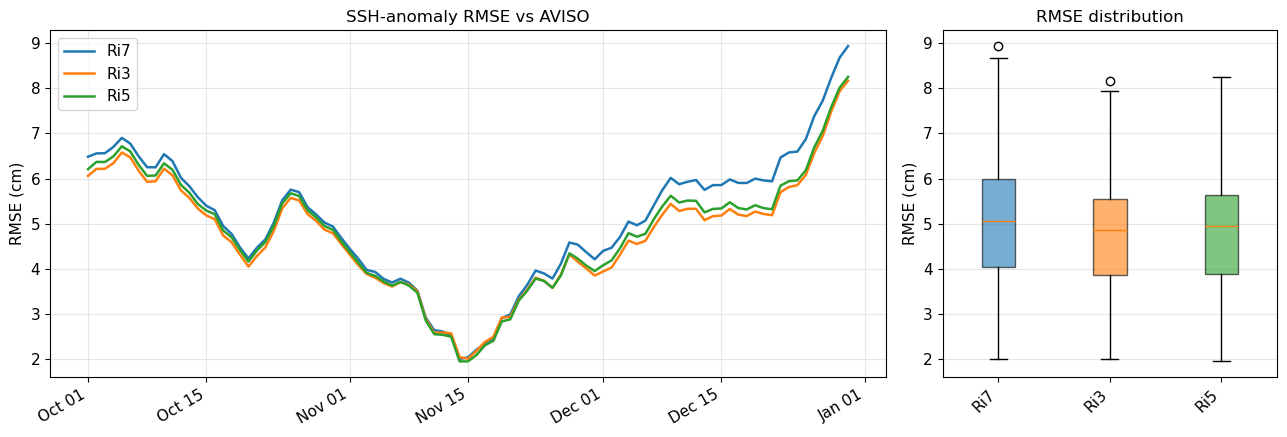

In [5]:
# ── 1-D: SSH-anomaly RMSE time series + box-plot summary ─────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5),
                         gridspec_kw={'width_ratios': [3, 1.2]})
tt = pd.to_datetime(time)
for i, (label, _) in enumerate(MODELS):
    axes[0].plot(tt, results[label]['anom_rmse_t'] * 100,
                 color=u.model_color(i), lw=1.8, label=label)
axes[0].set_title('SSH-anomaly RMSE vs AVISO')
axes[0].set_ylabel('RMSE (cm)'); axes[0].grid(alpha=0.3); axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha='right')

box = [results[l]['anom_rmse_t'] * 100 for l, _ in MODELS]
bp = axes[1].boxplot(box, labels=[l for l, _ in MODELS], patch_artist=True)
for k, patch in enumerate(bp['boxes']):
    patch.set_facecolor(u.model_color(k)); patch.set_alpha(0.6)
axes[1].set_title('RMSE distribution'); axes[1].set_ylabel('RMSE (cm)')
axes[1].grid(alpha=0.3, axis='y')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

fig.tight_layout()
fig.savefig(f'{OUTDIR}/aviso_1d_anom_rmse_timeseries.png', dpi=150,
            bbox_inches='tight')
plt.show()


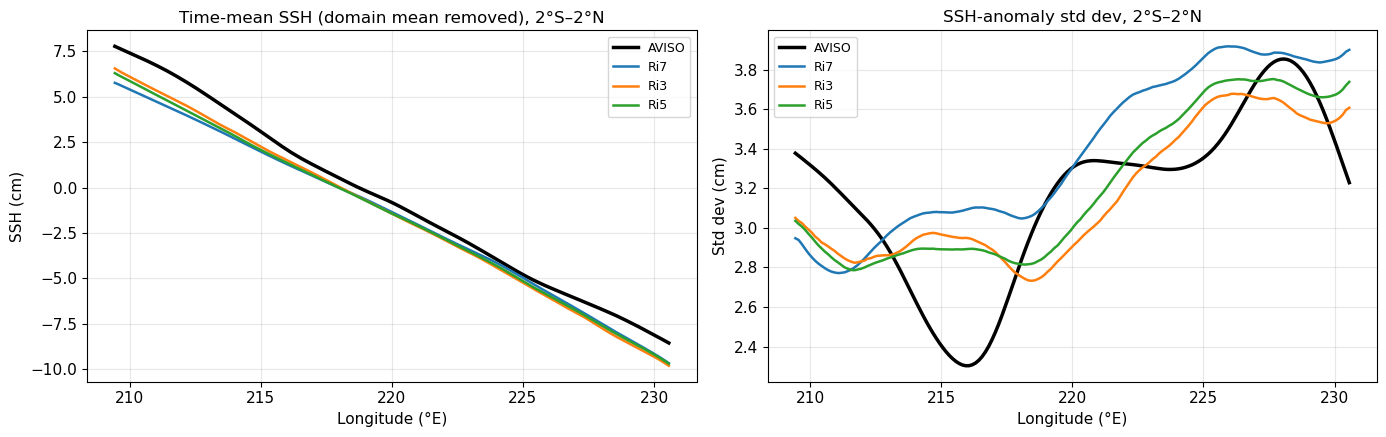

In [6]:
# ── 1-D: equatorial SSH tilt and anomaly variability vs longitude ────
band = np.abs(lat) <= 2.0
w = np.cos(np.deg2rad(lat[band]))[:, None]

def band_mean(arr2d):
    a = arr2d[band, :]
    return np.nansum(a * w, axis=0) / np.nansum(w * np.isfinite(a), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(lon, band_mean(obs_tmean) * 100, color='k', lw=2.5,
             label='AVISO')
for i, (label, _) in enumerate(MODELS):
    axes[0].plot(lon, band_mean(results[label]['tmean_map']) * 100,
                 color=u.model_color(i), lw=1.8, label=label)
axes[0].set_title('Time-mean SSH (domain mean removed), 2°S–2°N')
axes[0].set_ylabel('SSH (cm)')

axes[1].plot(lon, band_mean(obs_std_map) * 100, color='k', lw=2.5,
             label='AVISO')
for i, (label, _) in enumerate(MODELS):
    axes[1].plot(lon, band_mean(results[label]['std_map']) * 100,
                 color=u.model_color(i), lw=1.8, label=label)
axes[1].set_title('SSH-anomaly std dev, 2°S–2°N')
axes[1].set_ylabel('Std dev (cm)')
for ax in axes:
    ax.set_xlabel('Longitude (°E)'); ax.grid(alpha=0.3); ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(f'{OUTDIR}/aviso_1d_zonal_tilt_variability.png', dpi=150,
            bbox_inches='tight')
plt.show()


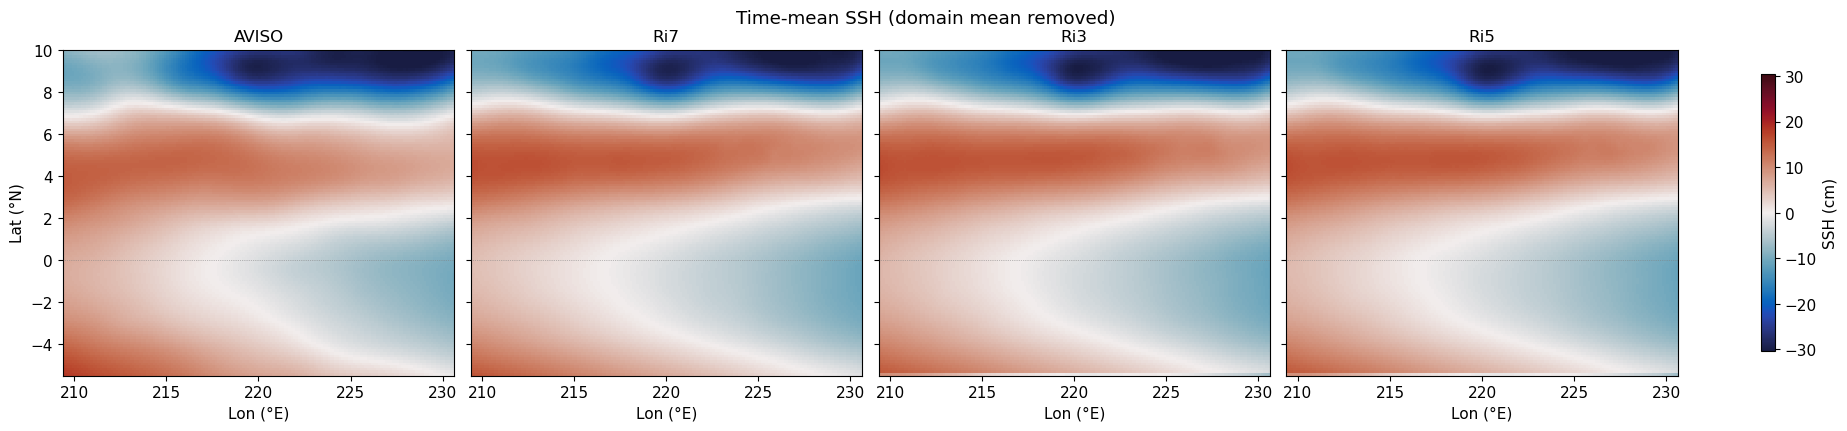

In [7]:
# ── 2-D: time-mean SSH (domain mean removed): AVISO + each model ─────
n = len(MODELS) + 1
allv = [obs_tmean] + [results[l]['tmean_map'] for l, _ in MODELS]
vmax = np.nanmax([np.nanpercentile(np.abs(a), 99) for a in allv]) * 100
fig, axes = plt.subplots(1, n, figsize=(4.6 * n, 4), sharex=True,
                         sharey=True, constrained_layout=True)
axes = np.atleast_1d(axes)
im = axes[0].pcolormesh(lon, lat, obs_tmean * 100, cmap=cmo.balance,
                        vmin=-vmax, vmax=vmax, shading='auto')
axes[0].set_title('AVISO')
for i, (label, _) in enumerate(MODELS):
    axes[i + 1].pcolormesh(lon, lat, results[label]['tmean_map'] * 100,
                           cmap=cmo.balance, vmin=-vmax, vmax=vmax,
                           shading='auto')
    axes[i + 1].set_title(label)
for ax in axes:
    ax.axhline(0, color='gray', lw=0.5, ls=':'); ax.set_xlabel('Lon (°E)')
axes[0].set_ylabel('Lat (°N)')
fig.colorbar(im, ax=axes, label='SSH (cm)', shrink=0.85)
fig.suptitle('Time-mean SSH (domain mean removed)', y=1.04)
fig.savefig(f'{OUTDIR}/aviso_2d_mean_ssh.png', dpi=150, bbox_inches='tight')
plt.show()


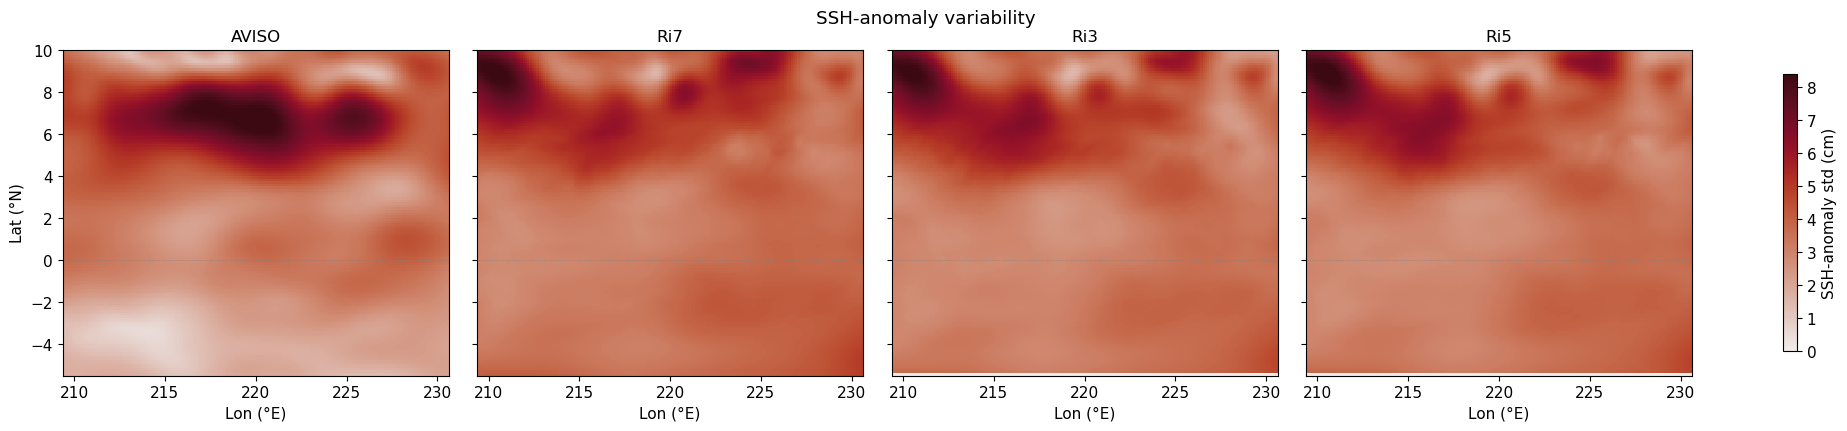

In [8]:
# ── 2-D: SSH-anomaly variability (std): AVISO + each model ───────────
n = len(MODELS) + 1
allv = [obs_std_map] + [results[l]['std_map'] for l, _ in MODELS]
vmax = np.nanmax([np.nanpercentile(a, 99) for a in allv]) * 100
fig, axes = plt.subplots(1, n, figsize=(4.6 * n, 4), sharex=True,
                         sharey=True, constrained_layout=True)
axes = np.atleast_1d(axes)
im = axes[0].pcolormesh(lon, lat, obs_std_map * 100, cmap=cmo.amp,
                        vmin=0, vmax=vmax, shading='auto')
axes[0].set_title('AVISO')
for i, (label, _) in enumerate(MODELS):
    axes[i + 1].pcolormesh(lon, lat, results[label]['std_map'] * 100,
                           cmap=cmo.amp, vmin=0, vmax=vmax, shading='auto')
    axes[i + 1].set_title(label)
for ax in axes:
    ax.axhline(0, color='gray', lw=0.5, ls=':'); ax.set_xlabel('Lon (°E)')
axes[0].set_ylabel('Lat (°N)')
fig.colorbar(im, ax=axes, label='SSH-anomaly std (cm)', shrink=0.85)
fig.suptitle('SSH-anomaly variability', y=1.04)
fig.savefig(f'{OUTDIR}/aviso_2d_anom_std.png', dpi=150, bbox_inches='tight')
plt.show()


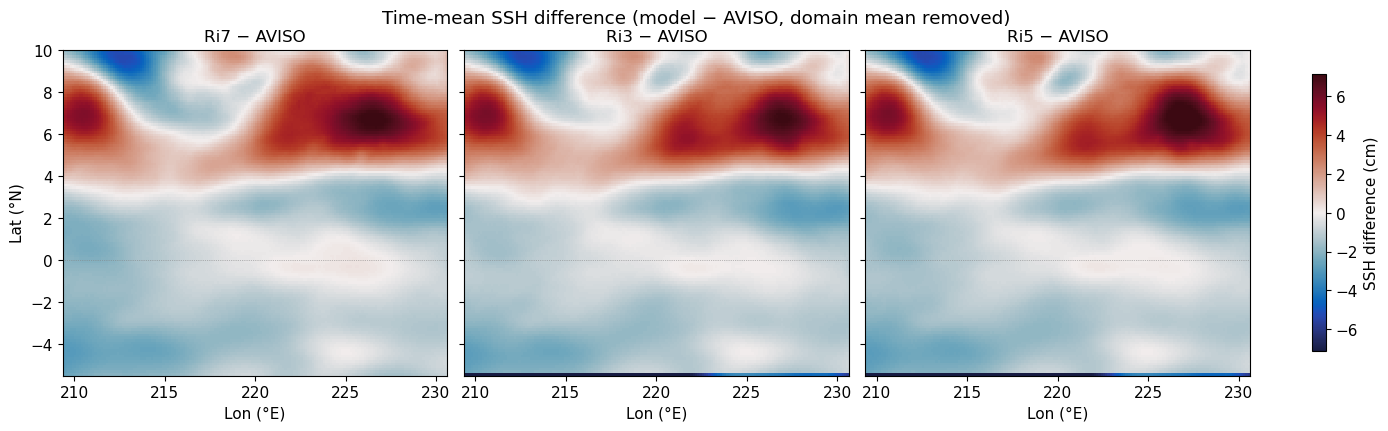

In [9]:
# ── 2-D: time-mean SSH difference (model − AVISO) ────────────────────
n = len(MODELS)
vmax = np.nanmax([np.nanpercentile(np.abs(results[l]['diff_tmean']), 99)
                  for l, _ in MODELS]) * 100
fig, axes = plt.subplots(1, n, figsize=(4.6 * n, 4), sharex=True,
                         sharey=True, constrained_layout=True)
axes = np.atleast_1d(axes)
for i, (label, _) in enumerate(MODELS):
    im = axes[i].pcolormesh(lon, lat, results[label]['diff_tmean'] * 100,
                            cmap=cmo.balance, vmin=-vmax, vmax=vmax,
                            shading='auto')
    axes[i].set_title(f'{label} − AVISO')
    axes[i].axhline(0, color='gray', lw=0.5, ls=':')
    axes[i].set_xlabel('Lon (°E)')
axes[0].set_ylabel('Lat (°N)')
fig.colorbar(im, ax=axes, label='SSH difference (cm)', shrink=0.85)
fig.suptitle('Time-mean SSH difference (model − AVISO, domain mean removed)',
             y=1.04)
fig.savefig(f'{OUTDIR}/aviso_2d_diff_maps.png', dpi=150, bbox_inches='tight')
plt.show()
